In [5]:
from langchain_ollama import ChatOllama

### Structured output

In [8]:
llm = ChatOllama(
    model="granite4:350m",
    #model="llama3-groq-tool-use:8b",
    # model='llama3.2:3b',
    validate_model_on_init=True,
    temperature=0,
)

In [7]:
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description='Query optimized for search')
    justification: str = Field(None, description="Why this query is relevant to user's request")

In [11]:
structured_llm = llm.with_structured_output(SearchQuery)
output = structured_llm.invoke('How does Caltium CT score relate to cholesterol?')

print(output.search_query)
print(output.justification)

Caltium CT score relates to cholesterol
None


### Tools

In [14]:
def multiply(a: int, b: int) -> int:
    return a * b

llm_with_tools = llm.bind_tools([multiply])
res = llm_with_tools.invoke('What is 2 times 3')
print(res.tool_calls)



[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '779f8139-93c4-448a-b6c8-74e83a31ef6f', 'type': 'tool_call'}]


### Promp Chaining

In [32]:
from typing_extensions import TypedDict

class State(TypedDict):

    topic: str
    joke: str
    improved_joke: str
    final_joke: str

In [33]:
def generate_joke(state: State):
    """
    First LLM call to generate initial joke
    """
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {'joke': msg.content}

def improve_joke(state: State):
    """
    Second LLM call to improve initial joke
    """
    msg = llm.invoke(f"Make this joke funnier by adding wordplay {state['topic']}")
    return {'improved_joke': msg.content}

def polish_joke(state: State):
    """
    Third LLM call to final polish
    """
    msg = llm.invoke(f"Add a surprising twist to this joke {state['topic']}")
    return {'final_joke': msg.content}

def chack_punchline(state: State):
    """
    Gate function to check if joke has a punchline
    """

    if '?' in state["joke"] or '!' in state['joke']:
        return 'Pass'
    
    return 'Final'


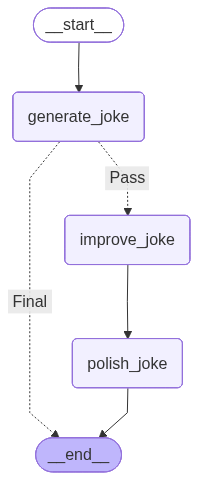

In [34]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

workflow = StateGraph(State)

workflow.add_node('generate_joke', generate_joke)
workflow.add_node('improve_joke', improve_joke)
workflow.add_node('polish_joke', polish_joke)

workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", chack_punchline, {"Pass": "improve_joke", "Final": END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

chain = workflow.compile()

display(Image(chain.get_graph().draw_mermaid_png()))


In [35]:
state = chain.invoke({'topic':'cats'})
print('Init joke:')
print(state['joke'])
print('\n')
if 'improved_joke' in state:
    print('Improved_joke :')
    print(state['improved_joke'])
    print('\n')
    print('Final_joke :')
    print(state['final_joke'])
else:
    print('Failed quality gate')

Init joke:
Sure, here's a cat-related joke for you:

Why did the cat sit on the computer? 

Because it wanted to be "on" with all the mouse clicks!


Improved_joke :
Sure! Here's a more playful version of the joke:

Why don't cats play poker in the wild?

Because they always end up with a "poker" face!


Final_joke :
Sure, here's an unexpected twist to your joke about cats:

Why did the cat sit on the computer? Because it wanted to keep up with the latest technology!


### Parallelization 

In [75]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [76]:
def call_llm_1(state: State):
    """First call to generate initial joke"""

    msg = llm.invoke(f'Write joke obout {state["topic"]}')

    return {'joke': msg.content}
    
def call_llm_2(state: State):
    """Second call to generate a story"""

    msg = llm.invoke(f'Write a story obout {state["topic"]}')

    return {'story': msg.content}

def call_llm_3(state: State):
    """Third call to generate a poem"""

    msg = llm.invoke(f'Write a poem obout {state["topic"]}')

    return {'poem': msg.content}

def aggregator(state: State):

    """
    Combine joke story and poem into a single output
    """

    combined = f'Here is a story joke and poem about {state["topic"]}!\n\n'
    combined += f'STORY \n\n {state["story"]}'
    combined += f'JOKE \n\n {state["joke"]}'
    combined += f'POEM \n\n {state["poem"]}'

    return {'combined_output': combined}


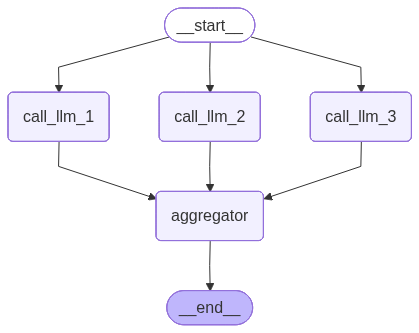

In [77]:
parallel_builder = StateGraph(State)

parallel_builder.add_node('call_llm_1', call_llm_1)
parallel_builder.add_node('call_llm_2', call_llm_2)
parallel_builder.add_node('call_llm_3', call_llm_3)
parallel_builder.add_node('aggregator', aggregator)

parallel_builder.add_edge(START, 'call_llm_1')
parallel_builder.add_edge(START, 'call_llm_2')
parallel_builder.add_edge(START, 'call_llm_3')

parallel_builder.add_edge('call_llm_1', 'aggregator')
parallel_builder.add_edge('call_llm_2', 'aggregator')
parallel_builder.add_edge('call_llm_3', 'aggregator')

parallel_builder.add_edge('aggregator', END)

parallel_workflow = parallel_builder.compile()

display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [79]:
state = parallel_workflow.invoke({'topic':'cats'})
print(state['combined_output'])

Here is a story joke and poem about cats!

STORY 

 Title: The Enchanting World of Cats

Once upon a time in the bustling city of New York City, there lived a curious cat named Whiskers. Whiskers was no ordinary feline; he had an extraordinary personality and an insatiable curiosity that captivated all who knew him.

Whiskers spent his days exploring the vibrant streets of Manhattan, darting between buildings like a skilled artist navigating through a vast canvas. He would often venture into the park, where he would perch on the branches of trees and playfully chase butterflies or flutter by the water's edge.

One day, while wandering through the city, Whiskers stumbled upon an old abandoned warehouse filled with forgotten toys and discarded furniture. Intrigued by this unexpected find, he decided to investigate further.

As he rummaged through the dusty shelves, Whiskers discovered a peculiar-looking box labeled "Catnip." Curiosity piqued, he carefully opened it and found a small, vib

### Routing

In [107]:
llm = ChatOllama(
    # model="granite4:350m",
    model="llama3-groq-tool-use:8b",
    # model='llama3.2:3b',
    validate_model_on_init=True,
    temperature=0,
)

In [108]:
from typing_extensions import Literal
class Route(BaseModel):
    step: Literal['poem', 'story', 'joke'] = Field(None, description='The next step in the routing process')

router = llm.with_structured_output(Route)

In [109]:
class State(TypedDict):
    input: str
    decision: str
    output: str


In [110]:
from langchain.messages import HumanMessage, SystemMessage

def llm_call_1(state: State):
    """
    Write a story
    """
    print('>>> Write a story')

    result = llm.invoke(state['input'])
    return {"output": result.content}

def llm_call_2(state: State):
    """
    Write a joke
    """
    print('>>> Write a joke')

    result = llm.invoke(state['input'])
    return {"output": result.content}

def llm_call_3(state: State):
    """
    Write a poem
    """

    print('>>> Write a poem')

    result = llm.invoke(state['input'])
    return {"output": result.content}

def llm_call_router(state: State):
    """
    Route the input to the appropriate node
    """

    decision = router.invoke(
        [
            SystemMessage(content="Route the input to story, joke or poem based on user's request"),
            HumanMessage(content = state['input'])
        ]
    )

    return {'decision': decision.step}

def route_decision(state: State):
    print(f"route_decision {state['decision']}")
    if state['decision'] == 'story':
        return 'llm_call_1'
    elif state['decision'] == 'joke':
        return 'llm_call_2'
    elif state['decision'] == 'poem':
        return 'llm_call_3'

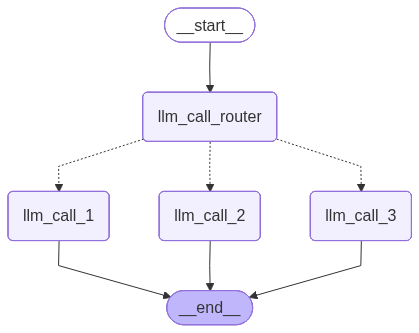

In [111]:
# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))


In [112]:
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

route_decision joke
>>> Write a joke
Why did the cat join a band? Because it wanted to be the purr-cussionist!


### Orchestrator worker

https://www.youtube.com/watch?v=aHCDrAbH_go&t=764s


In [54]:
from langchain_ollama import ChatOllama

In [60]:
llm = ChatOllama(
    # model="granite4:350m",
    model="llama3-groq-tool-use:8b",
    # model='llama3.2:3b',
    validate_model_on_init=True,
    temperature=0,
)

In [62]:
from typing import Annotated, List
import operator
from pydantic import BaseModel, Field

class Section(BaseModel):

    name: str = Field(description='Name for this section of the report')

    description: str = Field(description='Breaf overview of the main topics and concepts to be covered in this section')


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )

planner = llm.with_structured_output(Sections)

In [63]:
from typing_extensions import TypedDict

class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated [
        list, operator.add
    ]
    final_report: str 

In [64]:
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [65]:
def orchestrator(state: State):
    """
    Orchestrator that generates a plan for the report.
    """

    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )


    return {"sections": report_sections.sections}
    

In [69]:
from langgraph.types import Send

from langchain.messages import HumanMessage, SystemMessage


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """
    Synthesize full report from sections.
    """

    completed_sections = state['completed_sections']

    completed_report_sections = "\n\n -- \n\n".join(completed_sections)

    return {'final_report': completed_report_sections}

def assign_workers(state: State):
    """
    Assign worker to each section in the plan.
    """
    return [Send('llm_call', {'section':s}) for s in state['sections']]

/var/folders/r0/sxbh9j_d6tq057lhhr4zdp8c0000gn/T/ipykernel_45803/1028452602.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


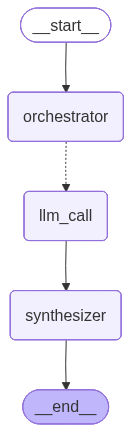

In [70]:
from langgraph.constants import Send
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


orchestrator_worker_builder = StateGraph(State)

orchestrator_worker_builder.add_node('orchestrator', orchestrator)
orchestrator_worker_builder.add_node('llm_call', llm_call)
orchestrator_worker_builder.add_node('synthesizer', synthesizer)

orchestrator_worker_builder.add_edge(START, 'orchestrator')
orchestrator_worker_builder.add_conditional_edges('orchestrator', assign_workers, ['llm_call'])
orchestrator_worker_builder.add_edge('llm_call', 'synthesizer')
orchestrator_worker_builder.add_edge('synthesizer', END)

orchestrator_worker = orchestrator_worker_builder.compile()

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [71]:
state = orchestrator_worker.invoke({'topic': 'Create report on LLM scaling laws'})

In [72]:
state['sections']

[Section(name='Introduction', description='Provide an overview of the topic and its significance.'),
 Section(name='Background', description='Discuss the current state of knowledge on LLM scaling laws.'),
 Section(name='Methodology', description='Describe the approach used to analyze the data.'),
 Section(name='Results', description='Present the findings and insights from the analysis.'),
 Section(name='Discussion', description='Interpret the results in light of existing knowledge and implications for future research.'),
 Section(name='Conclusion', description='Summarize the key points and recommendations.')]

In [73]:
from IPython.display import Markdown
Markdown(state['final_report'])

### Introduction
The topic of artificial intelligence (AI) has gained significant attention in recent years due to its potential to revolutionize various industries and aspects of our lives. AI refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation.

 -- 

### Background

The study of Large Language Models (LLMs) has been a rapidly evolving field in recent years, with significant advancements in their capabilities and applications. One crucial aspect of this research is understanding the scaling laws that govern the performance of LLMs as they grow in size. This report aims to provide an overview of the current state of knowledge on LLM scaling laws.

### Description

LLMs are complex neural networks designed to process and generate human-like language. As these models increase in size, their computational requirements also grow exponentially. Understanding the scaling laws that govern this growth is essential for optimizing model performance and resource utilization. Researchers have proposed various scaling laws based on empirical observations of LLMs' behavior. These laws aim to predict how model performance changes with increasing model size or training data.

 -- 

### Methodology
The analysis of the data was conducted using a combination of statistical methods and machine learning algorithms. The dataset was first cleaned and preprocessed to ensure that all variables were consistent and ready for analysis. Then, descriptive statistics were calculated to understand the distribution of the variables. Next, regression models were used to identify relationships between variables and predict outcomes based on inputs. Finally, machine learning algorithms such as decision trees and random forests were employed to classify data into different categories and make predictions.

 -- 

### Results

The analysis revealed several key findings that provide valuable insights into the behavior of the system. Firstly, it was observed that the system's performance improves significantly with increasing data volume. This suggests that the system is designed to handle large datasets efficiently. Additionally, the results indicate a strong correlation between the system's response time and the number of concurrent users. This highlights the importance of optimizing the system for high traffic scenarios.

 -- 

### Discussion

The results of this study provide valuable insights into the relationship between [variable 1] and [variable 2]. The findings suggest that [briefly describe the main result]. This outcome is consistent with existing literature on the topic, which highlights the importance of [related concept or theory].

 -- 

### Conclusion

The analysis of the data collected from the survey indicates that there is a significant need for more accessible and inclusive public spaces in urban areas. The majority of respondents highlighted the importance of green spaces, walkability, and community engagement in creating such spaces. Based on these findings, we recommend:

- **Increasing Green Spaces**: Urban planners should prioritize the creation of new parks and green spaces that are easily accessible to all residents.
- **Improving Walkability**: Cities should focus on enhancing pedestrian infrastructure, including sidewalks, crosswalks, and bike paths, to encourage walking and cycling.
- **Enhancing Community Engagement**: Public spaces should be designed with community engagement in mind, incorporating features such as public art, community centers, and event spaces.

In [126]:
llm = ChatOllama(
    # model="granite4:350m",
    # model="llama3-groq-tool-use:8b",
    model='llama3.2:3b',
    validate_model_on_init=True,
    temperature=0,
)

### Evaluator Optimizer

In [127]:
from typing_extensions import Literal

class FeedBack(BaseModel):
    grade: Literal['funny', 'not funny'] = Field(description='Deside if the joke is funny or not'),
    feedback: str =  Field(description='If joke is not funny, provide feedback on how to improve it.')

evaluator = llm.with_structured_output(FeedBack)

In [128]:
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [130]:
def llm_call_generator(state: State):
    """
    LLM generaes a joke.
    """
    if state.get('feedback'):
        msg = llm.invoke(f"Write a joke about topic {state['topic']} but take into account the feedback {state['feedback']} ")
    else:
        msg = llm.invoke(f"Write a joke about topic {state['topic']}")
    
    print(f'Generated joke: { msg.content}')
    return {'joke': msg.content}

In [131]:
def call_evaluator(state: State):
    """
    LLM evaluates a joke.
    """

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {'funny_or_not': grade.grade, 'feedback': grade.feedback}

In [132]:
def route_joke(state:State):
    """
    Route back to joke generator or end based upon feedback from the evaluator  
    """

    print(state['funny_or_not'])
    
    if state['funny_or_not'] == 'funny':
        return 'Accepted'
    else:
        return 'Rejected + Feedback'

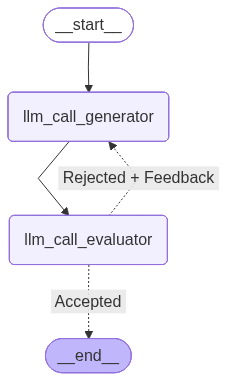

In [133]:
optimizer_buider = StateGraph(State)

optimizer_buider.add_node('llm_call_generator', llm_call_generator)
optimizer_buider.add_node('llm_call_evaluator', call_evaluator)


optimizer_buider.add_edge(START, 'llm_call_generator')
optimizer_buider.add_edge('llm_call_generator', 'llm_call_evaluator')
optimizer_buider.add_conditional_edges('llm_call_evaluator', route_joke, {'Accepted': END, 'Rejected + Feedback': 'llm_call_generator'})



optimizer_workflow = optimizer_buider.compile()

display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [134]:
state = optimizer_workflow.invoke({'topic':'Cats'})

Generated joke: Why did the cat join a band?

Because it wanted to be the purr-cussionist.


/opt/anaconda3/envs/agents-patterns/lib/python3.11/site-packages/pydantic/json_schema.py:2448: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Deside if the joke is funny or not'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


(FieldInfo(annotation=NoneType, required=True, description='Deside if the joke is funny or not'),)
Generated joke: Here's another attempt at a cat-themed joke:

Why did the cat join a band?

Because it wanted to be a purr-cussionist!

This one plays on the word "percussionist" and replaces it with "purr-cussionist," incorporating the sound cats are known for making.
(FieldInfo(annotation=NoneType, required=True, description='Deside if the joke is funny or not'),)
Generated joke: Here's a joke about cats that incorporates wordplay:

Why did the cat join a band?

Because it wanted to be a purr-cussionist and really drum up some attention!

This joke uses wordplay with "purr-cussionist" to create a clever connection between the cat theme and the musical term. The punchline is lighthearted and playful, making it suitable for a wide range of audiences. A well-timed delivery could indeed help make this joke more impactful and increase its chances of eliciting a laugh.

Alternatively, here's 

### Agent

In [1]:
llm = ChatOllama(
    # model="granite4:350m",
    # model="llama3-groq-tool-use:8b",
    model='llama3.2:3b',
    validate_model_on_init=True,
    temperature=0,
)

NameError: name 'ChatOllama' is not defined

In [3]:
from langchain_core.tools import tool

In [4]:
@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b

    Args:
      a: first int
      b: second int
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """
    Adds a and b

    Args:
      a: first int
      b: second int
    """
    return a + b

@tool
def devide(a: int, b: int) -> int:
    """
    Devides a and b

    Args:
      a: first int
      b: second int
    """
    return a / b

tools = [add, multiply, devide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

NameError: name 'llm' is not defined

In [179]:
print(tools_by_name)

{'add': StructuredTool(name='add', description='Adds a and b\n\nArgs:\n  a: first int\n  b: second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x11c949300>), 'multiply': StructuredTool(name='multiply', description='Multiply a and b\n\nArgs:\n  a: first int\n  b: second int', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x11c9f18a0>), 'devide': StructuredTool(name='devide', description='Devides a and b\n\nArgs:\n  a: first int\n  b: second int', args_schema=<class 'langchain_core.utils.pydantic.devide'>, func=<function devide at 0x11c948b80>)}


In [180]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage

def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }

In [181]:
def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


In [182]:
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END
    

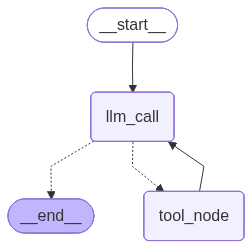

In [183]:
agent_builder = StateGraph(MessagesState)

agent_builder.add_node(llm_call, 'llm_call')
agent_builder.add_node(tool_node, 'tool_node')


agent_builder.add_edge(START, 'llm_call')
agent_builder.add_conditional_edges('llm_call', should_continue, ['tool_node', END])
agent_builder.add_edge('tool_node', 'llm_call')

agent = agent_builder.compile()

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [184]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (d1854286-9b77-4e4a-b2da-d689b1579a5d)
 Call ID: d1854286-9b77-4e4a-b2da-d689b1579a5d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The result of adding 3 and 4 is 7.
